In [31]:
import pandas as pd
import numpy as np
from scipy.io import arff
import os

data = arff.loadarff('data/raw/Training Dataset.arff')
df = pd.DataFrame(data[0])

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.decode('utf-8')

df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [32]:
print(f"Liczba wierszy: {df.shape[0]}")
print(f"Liczba kolumn (cech + etykieta): {df.shape[1]}")
print("\n--- Podstawowe informacje o zbiorze ---")
df.info()

Liczba wierszy: 11055
Liczba kolumn (cech + etykieta): 31

--- Podstawowe informacje o zbiorze ---
<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  str  
 1   URL_Length                   11055 non-null  str  
 2   Shortining_Service           11055 non-null  str  
 3   having_At_Symbol             11055 non-null  str  
 4   double_slash_redirecting     11055 non-null  str  
 5   Prefix_Suffix                11055 non-null  str  
 6   having_Sub_Domain            11055 non-null  str  
 7   SSLfinal_State               11055 non-null  str  
 8   Domain_registeration_length  11055 non-null  str  
 9   Favicon                      11055 non-null  str  
 10  port                         11055 non-null  str  
 11  HTTPS_token                  11055 non-null  str  
 12  Request_URL   

In [33]:
target_col = df.columns[-1]
features = df.columns[:-1]

df_missing = df.copy()

np.random.seed(42)

for col in features:
    missing_indices = np.random.choice(df.index, size=int(len(df)*0.10), replace=False)
    df_missing.loc[missing_indices, col] = np.nan

print("Liczba braków w poszczególnych kolumnach:\n", df_missing.isnull().sum().head(10))

os.makedirs('data/processed', exist_ok=True)
df_missing.to_csv('data/processed/phishing_missing.csv', index=False)

Liczba braków w poszczególnych kolumnach:
 having_IP_Address              1105
URL_Length                     1105
Shortining_Service             1105
having_At_Symbol               1105
double_slash_redirecting       1105
Prefix_Suffix                  1105
having_Sub_Domain              1105
SSLfinal_State                 1105
Domain_registeration_length    1105
Favicon                        1105
dtype: int64


In [34]:
missing_data = df_missing.isnull().sum()
missing_percent = (df_missing.isnull().sum() / len(df_missing)) * 100

missing_df = pd.DataFrame({
    'Liczba braków': missing_data,
    'Procent braków [%]': missing_percent
})

print("Podsumowanie braków danych w kolumnach (top 10):")
display(missing_df.head(10))

print(f"\nBraki w kolumnie Result: {df_missing['Result'].isnull().sum()}")

Podsumowanie braków danych w kolumnach (top 10):


,Liczba braków,Procent braków [%]
having_IP_Address,1105,9.995477
URL_Length,1105,9.995477
Shortining_Service,1105,9.995477
having_At_Symbol,1105,9.995477
double_slash_redirecting,1105,9.995477
Prefix_Suffix,1105,9.995477
having_Sub_Domain,1105,9.995477
SSLfinal_State,1105,9.995477
Domain_registeration_length,1105,9.995477
Favicon,1105,9.995477



Braki w kolumnie Result: 0


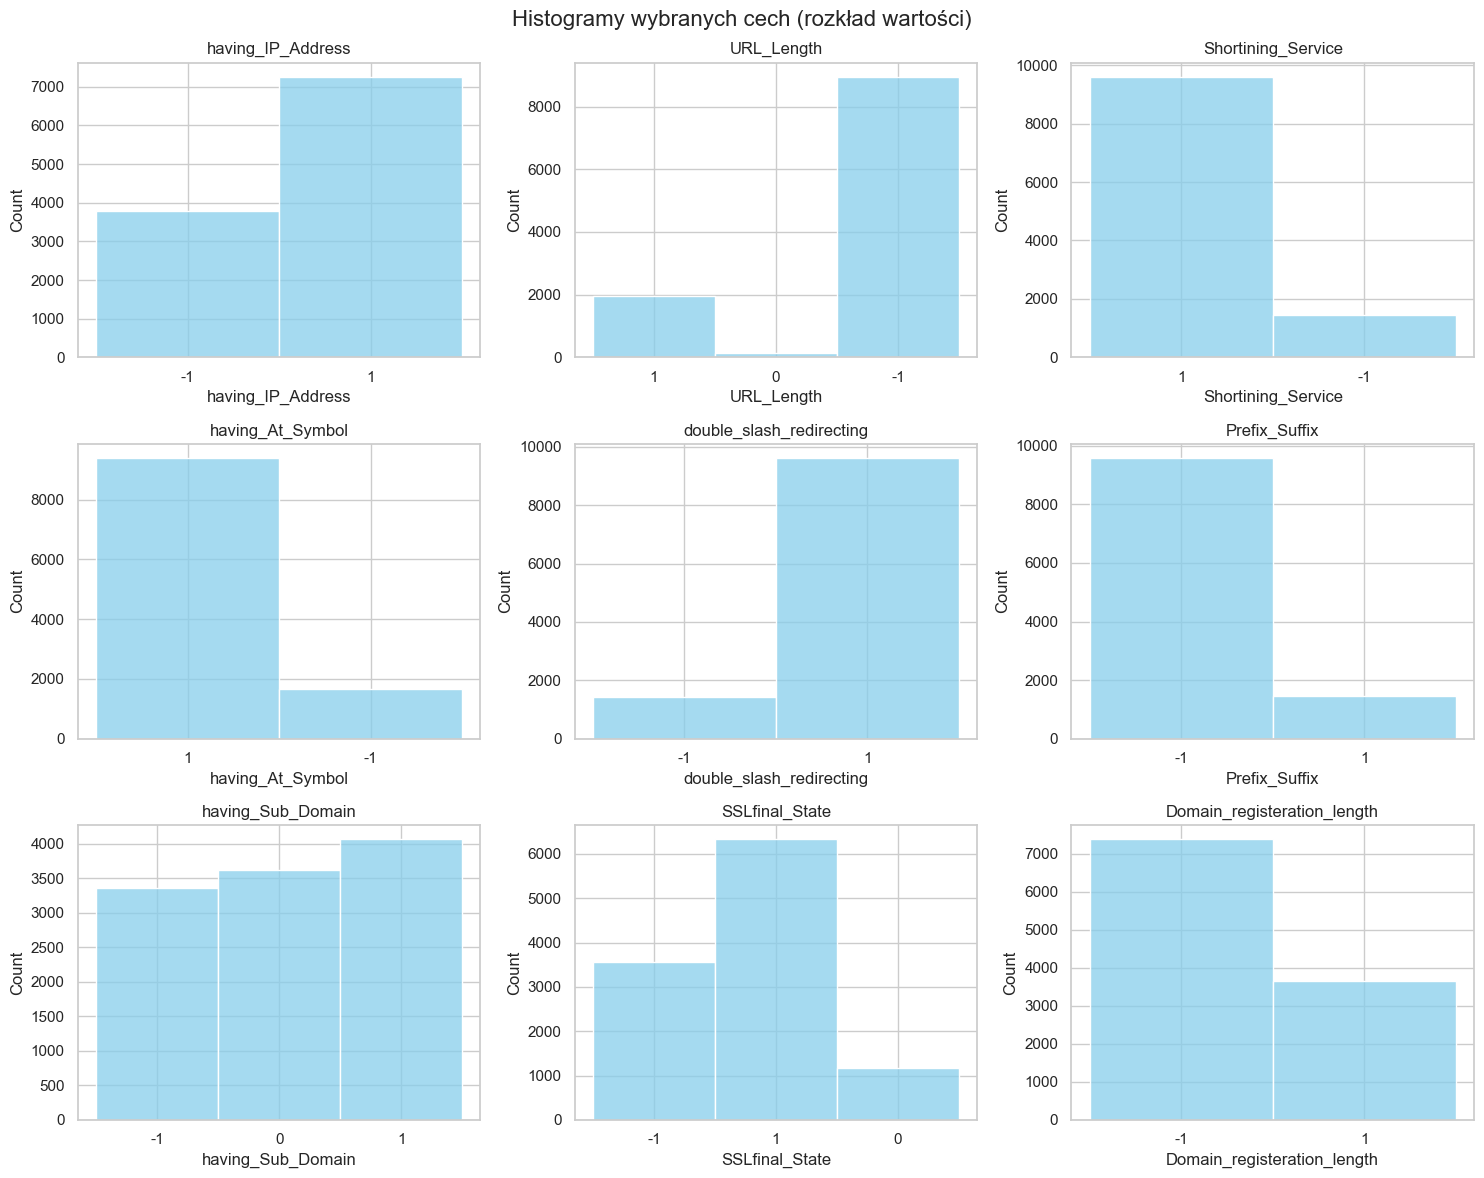

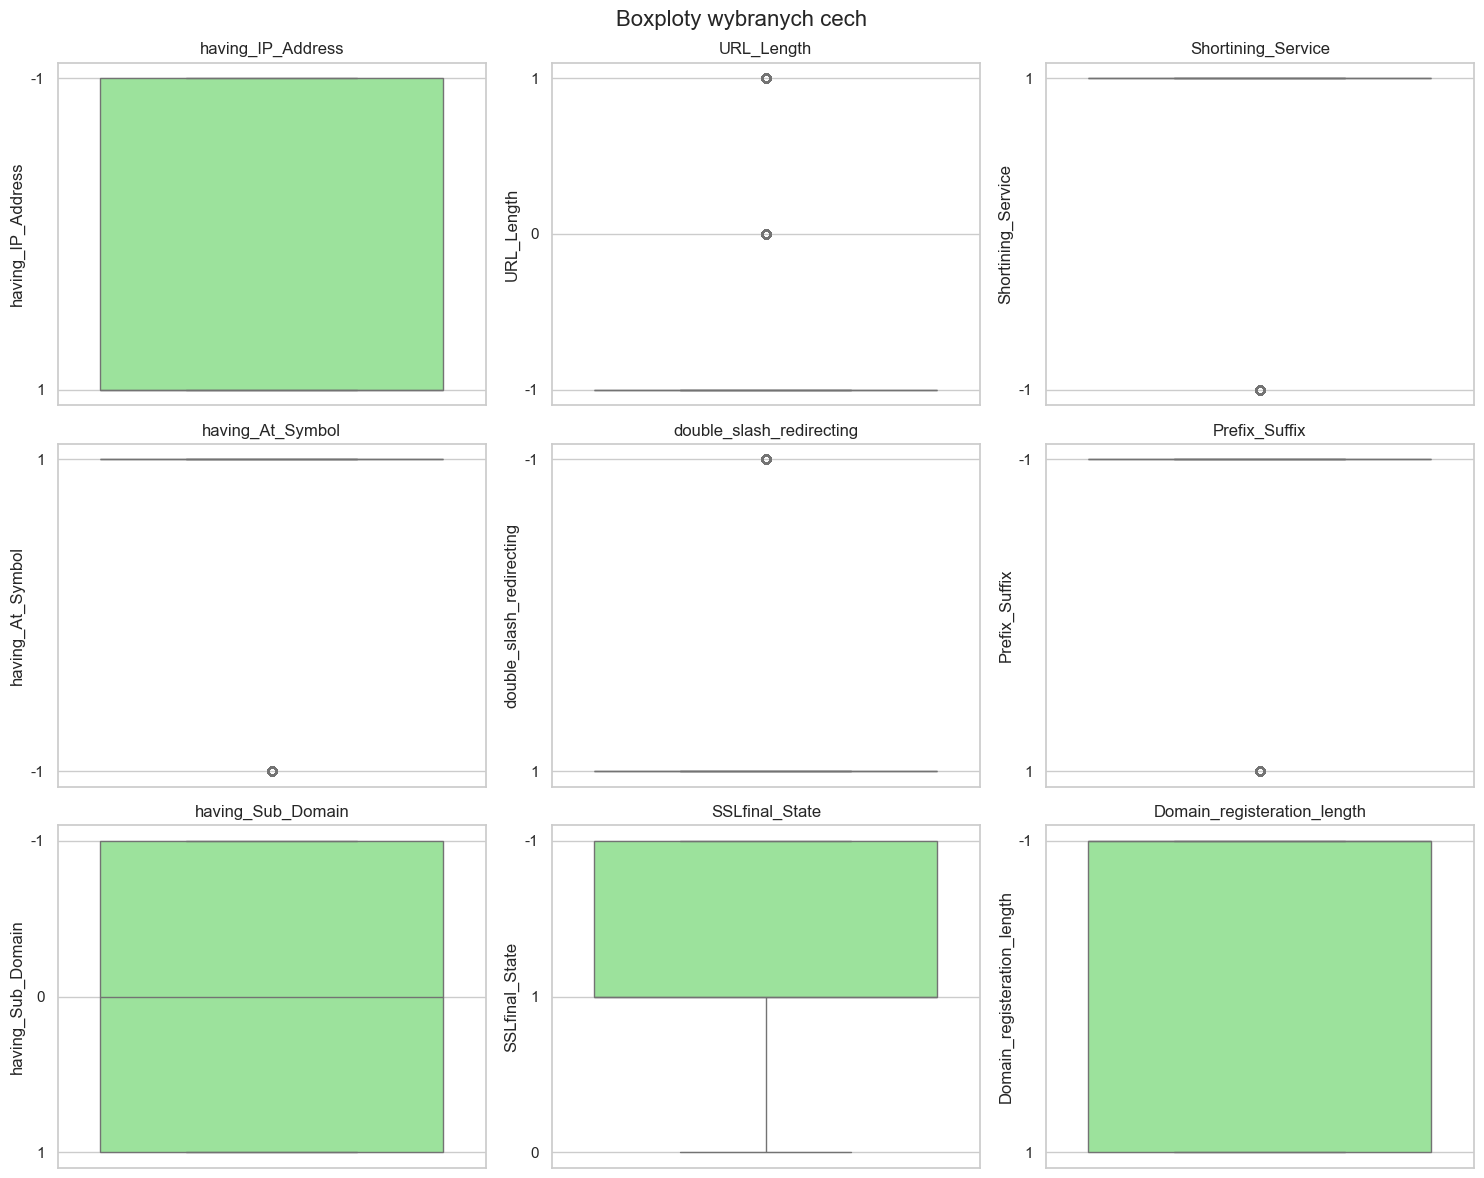

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Histogramy wybranych cech (rozkład wartości)', fontsize=16)

cols_to_plot = df.columns[:9]

for i, col in enumerate(cols_to_plot):
    row, a_col = i // 3, i % 3
    sns.histplot(df[col], bins=3, ax=axes[row, a_col], kde=False, color='skyblue')
    axes[row, a_col].set_title(col)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Boxploty wybranych cech', fontsize=16)

for i, col in enumerate(cols_to_plot):
    row, a_col = i // 3, i % 3
    sns.boxplot(y=df[col], ax=axes[row, a_col], color='lightgreen')
    axes[row, a_col].set_title(col)

plt.tight_layout()
plt.show()

In [36]:
df = df.apply(pd.to_numeric)

grouped_data = df.groupby('Result').mean().T

grouped_data.columns = ['Legitna strona (-1)', 'Phishing (1)']

grouped_data['Różnica'] = abs(grouped_data['Legitna strona (-1)'] - grouped_data['Phishing (1)'])

top_features = grouped_data.sort_values(by='Różnica', ascending=False).head(10)

print("Top 10 cech najbardziej różnicujących strony phishingowe od bezpiecznych (wg średniej):")
display(top_features)

Top 10 cech najbardziej różnicujących strony phishingowe od bezpiecznych (wg średniej):


,Legitna strona (-1),Phishing (1),Różnica
SSLfinal_State,-0.479788,0.832223,1.312011
URL_of_Anchor,-0.632095,0.365438,0.997532
web_traffic,-0.033891,0.542797,0.576688
Request_URL,-0.092283,0.408803,0.501086
having_Sub_Domain,-0.209473,0.281468,0.490942
Prefix_Suffix,-1.000000,-0.524119,0.475881
Domain_registeration_length,-0.098408,-0.526393,0.427985
Links_in_tags,-0.330747,0.050999,0.381746
SFH,-0.784198,-0.445834,0.338364
age_of_domain,-0.074724,0.169401,0.244125


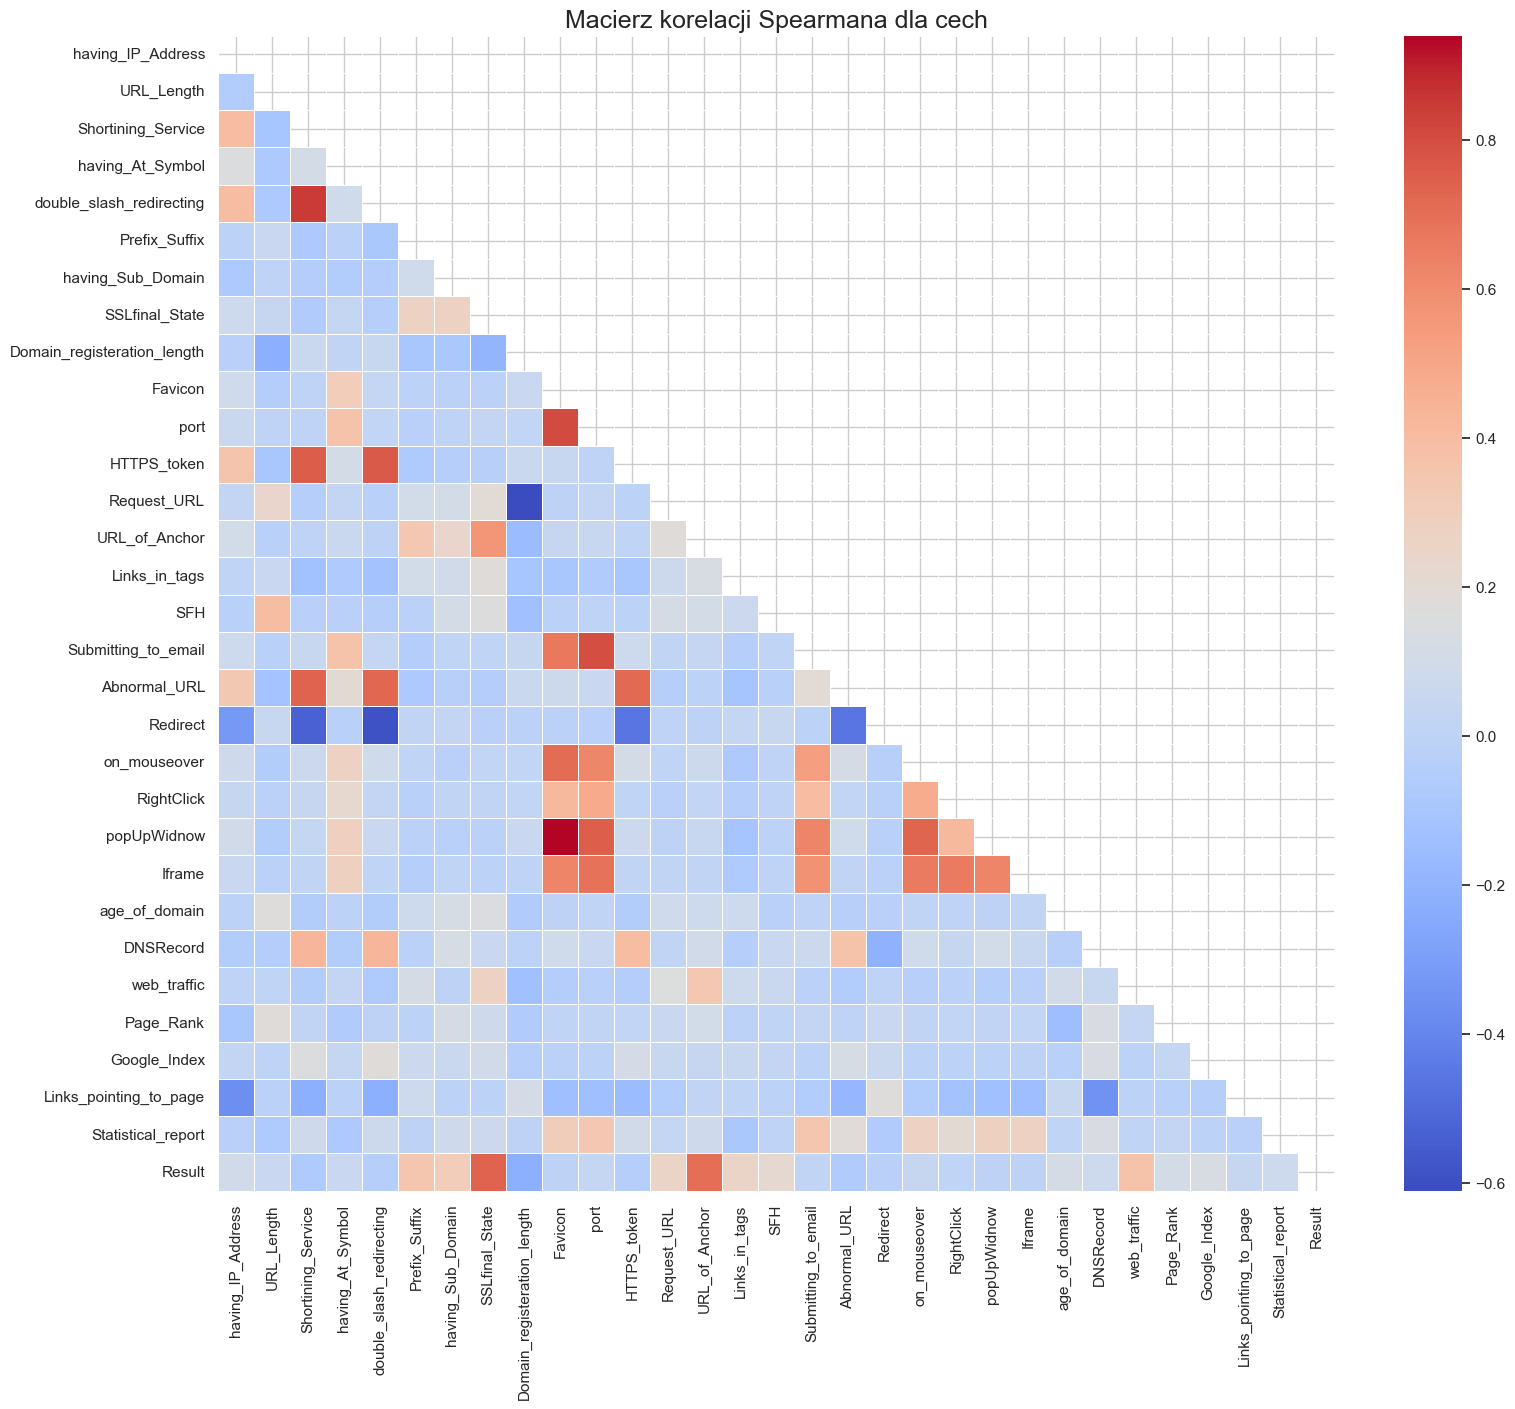


Korelacja cech z kolumną docelową (Result):
Result            1.000000
SSLfinal_State    0.735814
URL_of_Anchor     0.701207
web_traffic       0.365118
Prefix_Suffix     0.348606
Name: Result, dtype: float64
Domain_registeration_length   -0.225789
Shortining_Service            -0.067966
Abnormal_URL                  -0.060488
HTTPS_token                   -0.039854
double_slash_redirecting      -0.038608
Name: Result, dtype: float64


In [37]:
plt.figure(figsize=(18, 15))
plt.title("Macierz korelacji Spearmana dla cech", fontsize=18)

corr_matrix = df.corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)

plt.show()

print("\nKorelacja cech z kolumną docelową (Result):")
print(corr_matrix['Result'].sort_values(ascending=False).head(5))
print(corr_matrix['Result'].sort_values(ascending=True).head(5))